In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("../data/raw/spam.csv", encoding="ISO-8859-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
### Insights
### There are 3 extra default unnamed columns that I need to remove.

In [8]:
df = df[['v1', 'v2']]

In [ ]:
### Insights
### I have only allowed two columns v1 and v2

In [11]:
print(df.columns.tolist())

['v1', 'v2']


In [ ]:
### Insights
### There are only 2 columns now, V1 abd V2

In [9]:
print("Shape:", df.shape)
df.info()

Shape: (5572, 2)
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB


In [19]:
### Insights
### Dataset contains 5572 entries

In [10]:
df.isnull().sum()

v1    0
v2    0
dtype: int64

In [ ]:
### Insights
### Dataset does not have any missing values

In [12]:
df.columns = ['label', 'message']

In [13]:
print(df.columns.tolist())

['label', 'message']


In [ ]:
### Insights
### I have renamed 'v1' and 'v2' to 'label' and 'message' respectively

In [14]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


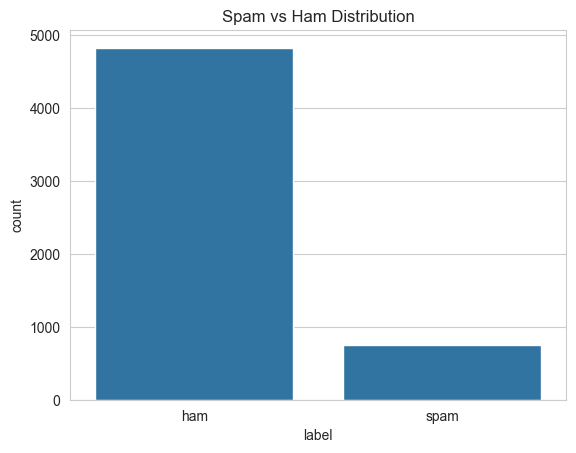

In [15]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Distribution")
plt.show()

In [ ]:
### Insights
### Spam and Ham are unevenly distributed

In [16]:
df['length'] = df['message'].apply(len)
df.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [17]:
df.groupby('label')['length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
spam,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


In [ ]:
### Insights
### When we consider the 'mean' we see that 'spam' messages are much longer in general compared to 'ham' messages i.e. 71.02 (ham) and 138.86 (spam)
### Spam messages have less variation i.e 29.18 vs the 58.01 in ham because spam are mostly autogenerated bulk messages while ham relies on human choice.
### Ham messages have alot of very noticeable outliers i.e 910.0 vs the 224.0 in spam. This is due to the fact that humans tend to right messages of varied lengths natuarally.

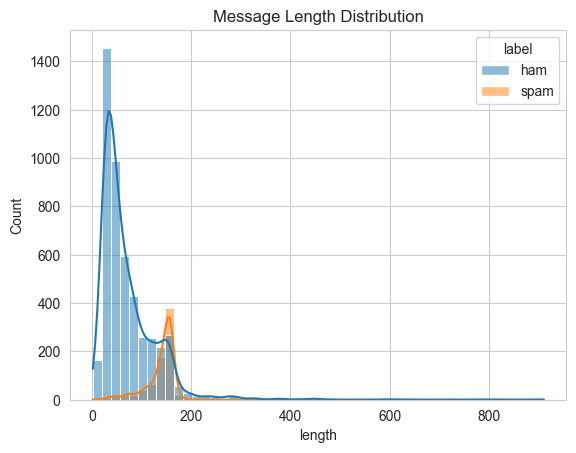

In [18]:
sns.histplot(data=df, x='length', hue='label', bins=50, kde=True)
plt.title("Message Length Distribution")
plt.show()

In [20]:
### Insights
### A graph representing a comparison of the message length distribution of 'ham' vs 'spam'